모델 훈련을 시작합니다...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8384 - loss: 0.4442
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8911 - loss: 0.2985
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9079 - loss: 0.2496
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9194 - loss: 0.2166
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9293 - loss: 0.1905
313/313 - 1s - 4ms/step - accuracy: 0.9020 - loss: 0.2680

테스트 정확도: 0.9020
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


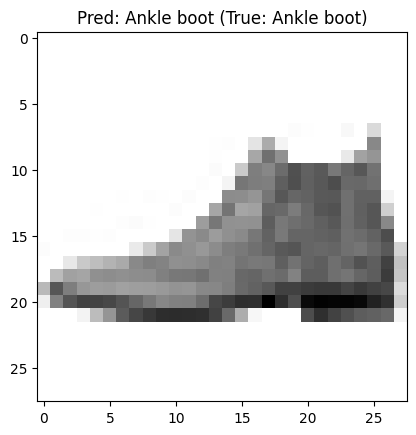

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 1. 데이터 로드 및 전처리
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# 픽셀 값을 0~1 사이로 정규화
train_images = train_images / 255.0
test_images = test_images / 255.0

# CNN 입력을 위해 차원 변경 (28x28 -> 28x28x1)
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

# 2. CNN 모델 구성
model = models.Sequential([
    # 첫 번째 합성곱 층: 3x3 크기의 32개 필터 사용
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # 두 번째 합성곱 층: 64개 필터 사용
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 평탄화 및 완전 연결 층
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    # 출력층: 10개의 클래스에 대한 확률 반환
    layers.Dense(10, activation='softmax')
])

# 3. 모델 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. 모델 훈련
print("모델 훈련을 시작합니다...")
model.fit(train_images, train_labels, epochs=5)

# 5. 모델 평가
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\n테스트 정확도: {test_acc:.4f}')

# 6. 예측 및 시각화 (첫 번째 테스트 이미지)
predictions = model.predict(test_images)
predicted_label = np.argmax(predictions[0])
true_label = test_labels[0]

plt.figure()
plt.imshow(test_images[0].reshape(28, 28), cmap=plt.cm.binary)
plt.title(f"Pred: {class_names[predicted_label]} (True: {class_names[true_label]})")
plt.show()